# For defining, validating, and expnading scope of reaction templates

In [8]:
# File I/O
import json
from collections import defaultdict
from pathlib import Path

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import rdChemReactions

# Custom Imports
from polymerist.rdutils.reactions.reactions import AnnotatedReaction

from polymerist.smileslib.functgroups import FN_GROUP_TABLE
from polymerist.polymers.monomers import specification

from src.reactions import rxns, rxn_smarts, rxn_assemblers, rxn_inputs, test_reactants_catalogue

## Inspecting defined reaction assemblers

### Define functional groups (with R-group linkers) as basis for desired reactions

polyester {1: (3, 5), 4: (5, 3)}


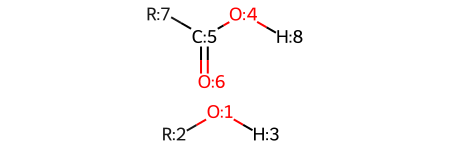

polyamide {1: (3, 6), 5: (6, 3)}


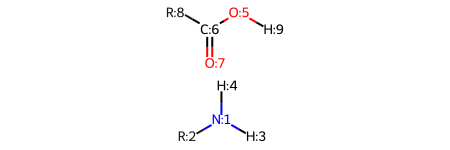

polyimide {4: (1, 8), 6: (8, 1), 3: (1, 8), 9: (8, 1)}


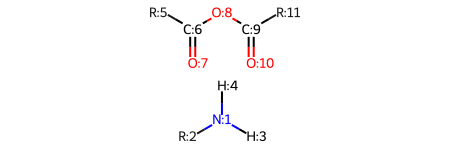

polycarbonate_phosgene {1: (3, 5), 4: (5, 3)}


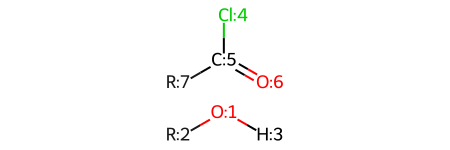

polycarbonate_nonphosgene {5: (6, 3), 1: (3, 6)}


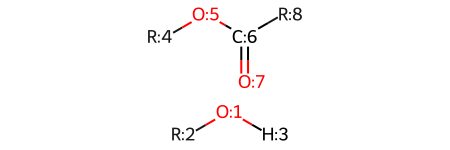

polyurethane_isocyanate {7: (5, 3), 2: (3, 5)}


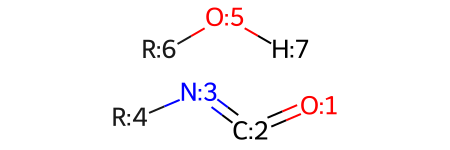

polyurethane_nonisocyanate {5: (4, 11), 13: (11, 4)}


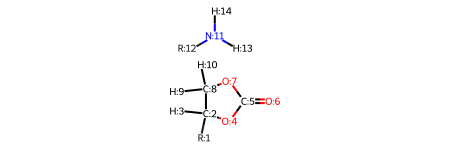

polyvinyl_head_tail {4: (2, 8), 12: (8, 2)}


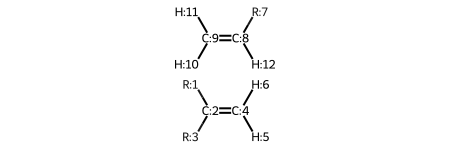

In [9]:
# display mechanism schemata prior to generating reactions (allows for inspection of derangement IDs)
for mech_name, mech_schema in rxn_assemblers.items():
    print(mech_name, mech_schema.bond_derangement)
    display(mech_schema.reactants)

polyester
1 --x-> 3


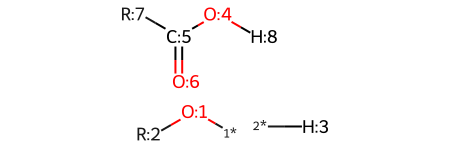

4 --x-> 5


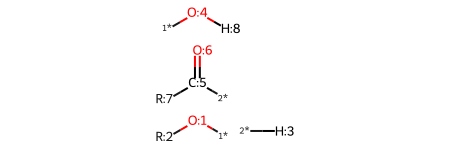

1 ----> 5


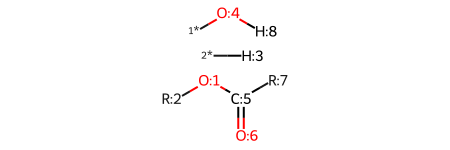

4 ----> 3


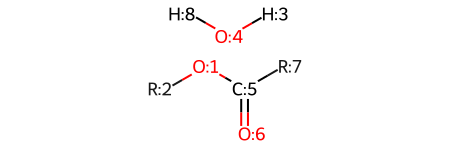

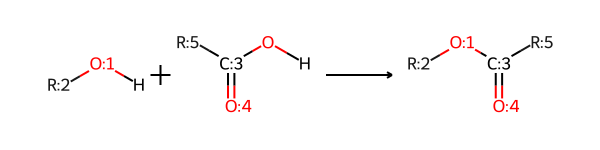

polyamide
1 --x-> 3


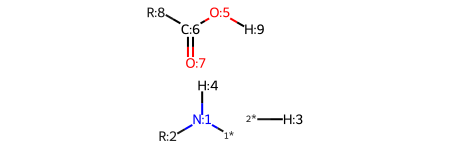

5 --x-> 6


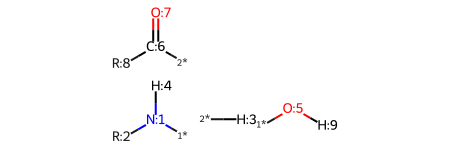

1 ----> 6


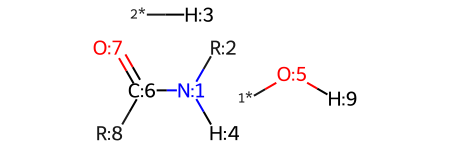

5 ----> 3


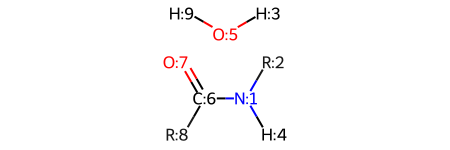

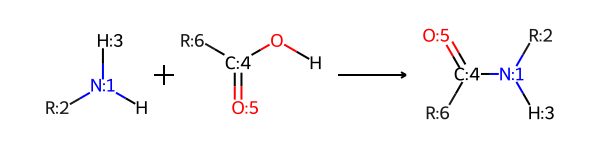

polyimide
4 --x-> 1


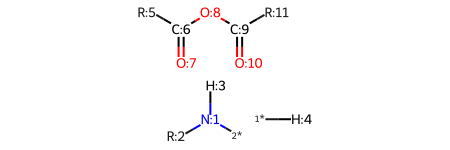

6 --x-> 8


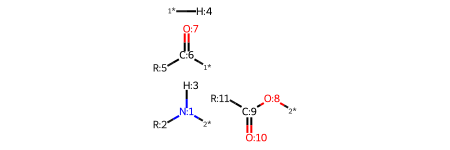

3 --x-> 1


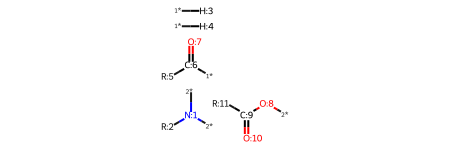

9 --x-> 8


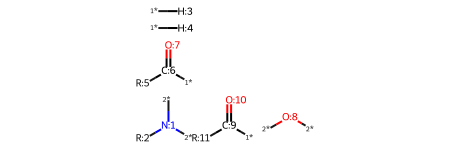

4 ----> 8


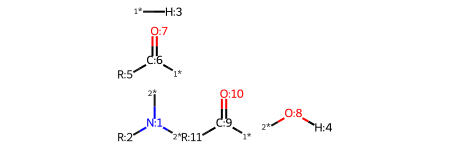

6 ----> 1


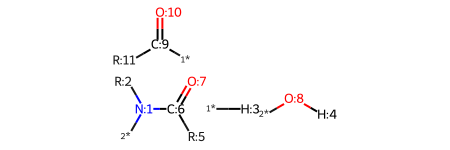

3 ----> 8


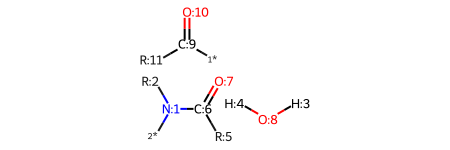

9 ----> 1


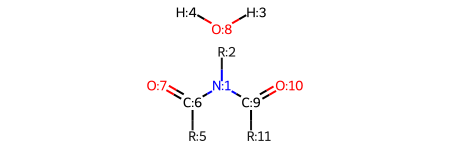

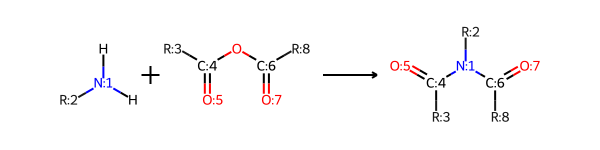

polycarbonate_phosgene
1 --x-> 3


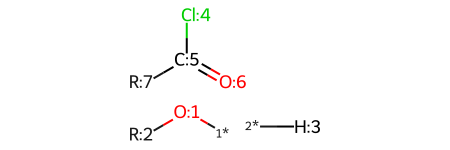

4 --x-> 5


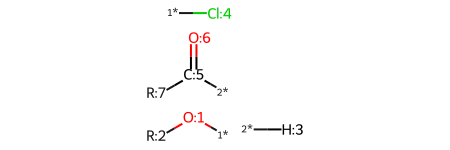

1 ----> 5


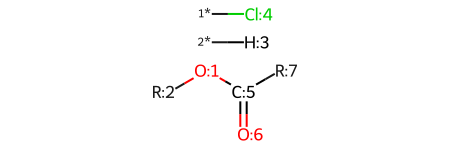

4 ----> 3


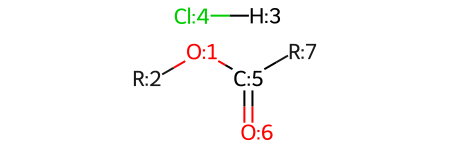

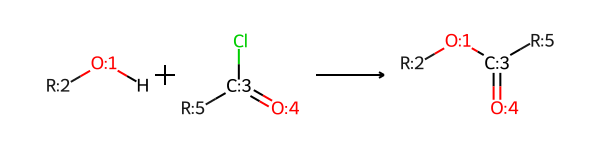

polycarbonate_nonphosgene
5 --x-> 6


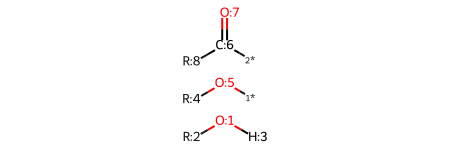

1 --x-> 3


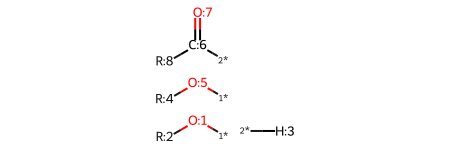

5 ----> 3


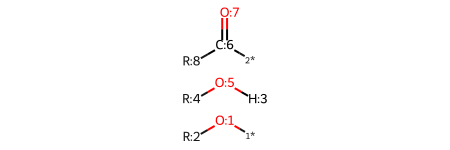

1 ----> 6


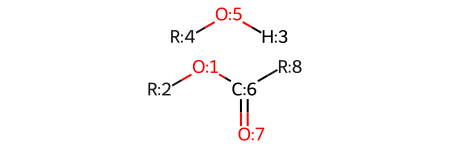

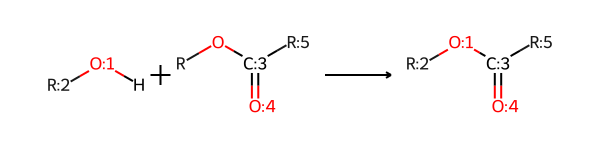

polyurethane_isocyanate
7 --x-> 5


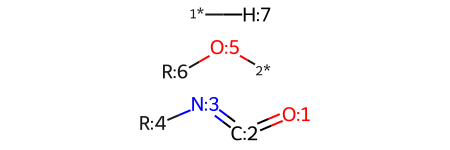

2 --x-> 3


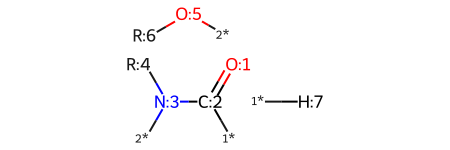

7 ----> 3


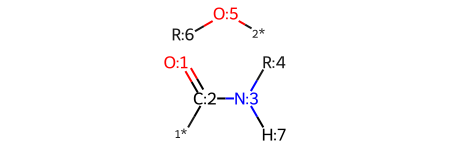

2 ----> 5


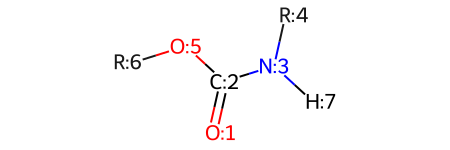

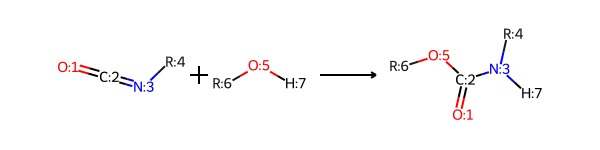

polyurethane_nonisocyanate
5 --x-> 4


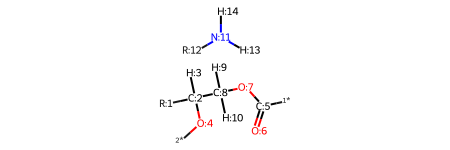

13 --x-> 11


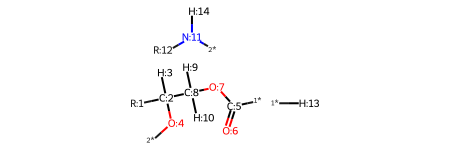

5 ----> 11


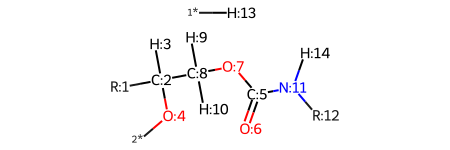

13 ----> 4


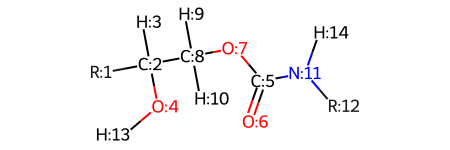

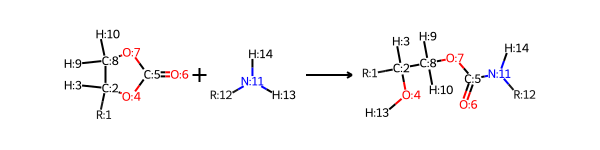

polyvinyl_head_tail
4 --x-> 2


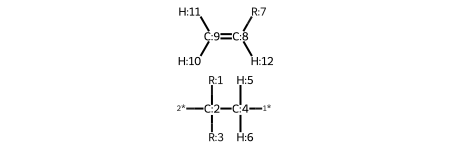

12 --x-> 8


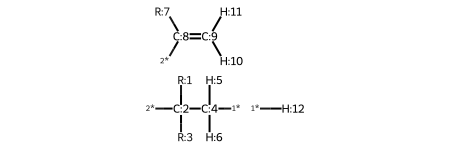

4 ----> 8


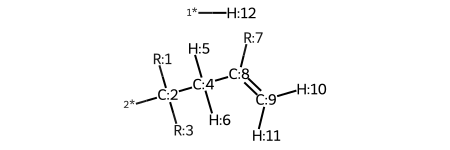

12 ----> 2


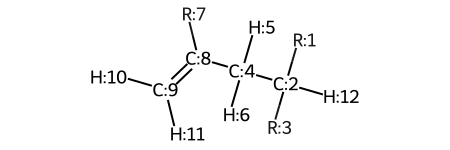

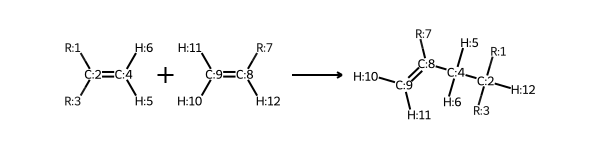

In [10]:
for mech_name, mech_schema in rxn_assemblers.items():
    # assemble reaction
    print(mech_name)
    rxn = mech_schema.assemble_rxn(show_steps=True)
    rxn.rxnname = mech_name # store mechanism name for reference
    display(rxn)

# Testing that reaction actually behave as intended

0 0


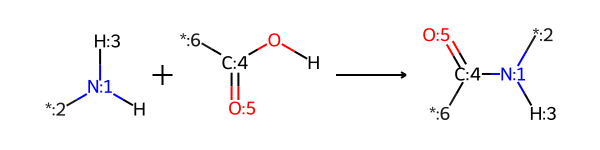

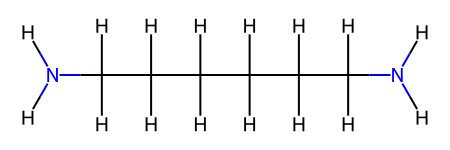

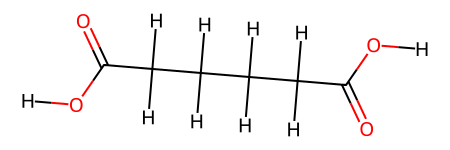

In [11]:
# mechanism = 'polycarbonate_nonphosgene'
# mechanism = 'polyurethane_nonisocyanate'
# mechanism = 'polyimide'
mechanism = 'polyamide'

smarts = rxn_smarts[mechanism]
rxn = AnnotatedReaction.from_smarts(smarts)
rxn.Initialize()
num_warnings, num_errors = rxn.Validate()
print(num_warnings, num_errors)
display(rxn)

test_reactants = test_reactants_catalogue[mechanism]
for reactant in test_reactants:
    display(reactant)

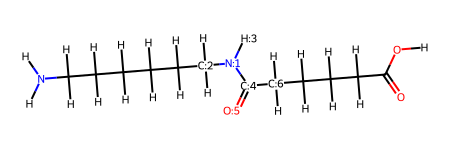

In [12]:
from polymerist.rdutils.reactions import reactors

reactor = reactors.PolymerizationReactor(rxn)
for product in reactor.react(test_reactants):
    display(product)

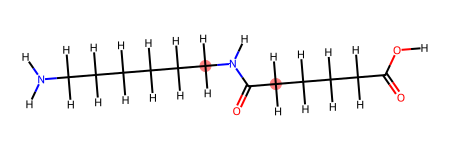

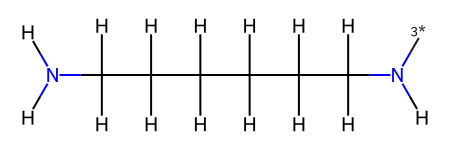

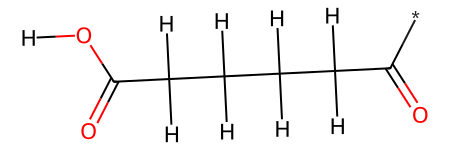

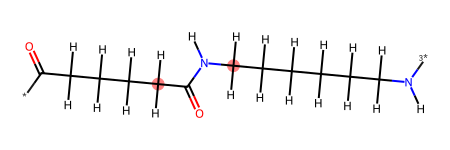

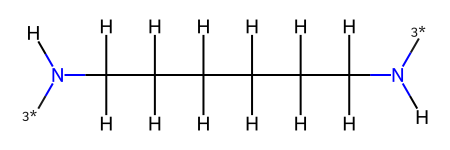

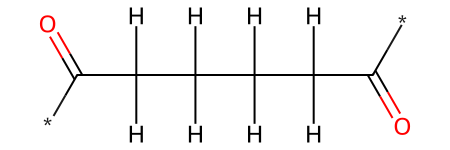

In [13]:
for intermeds, frags in reactor.propagate(test_reactants):
    for inter in intermeds:
        display(inter)

    for frag in frags:
        display(frag)
    print('='*50)